## Creates the **Grid File** of a specific region by converting the available shapefile into mutliple (X,Y) coordinate pairs to represent each NUTS3 Unit ##

In [1]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np
import missingno

import sys

sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")


from utils import process_greek, create_grid, remove_accents

enc = 'utf-8'
dec = 'greek8'
random.seed(0)
np.random.seed(0)

In [2]:
GREEK_TO_EN = str.maketrans({
    "Α": "A", "Β": "V", "Γ": "G", "Δ": "D", "Ε": "E", "Ζ": "Z", "Η": "I", "Θ": "TH",
    "Ι": "I", "Κ": "K", "Λ": "L", "Μ": "M", "Ν": "N", "Ξ": "X", "Ο": "O", "Π": "P",
    "Ρ": "R", "Σ": "S", "Τ": "T", "Υ": "Y", "Φ": "F", "Χ": "CH", "Ψ": "PS", "Ω": "O",
    "α": "a", "β": "v", "γ": "g", "δ": "d", "ε": "e", "ζ": "z", "η": "i", "θ": "th",
    "ι": "i", "κ": "k", "λ": "l", "μ": "m", "ν": "n", "ξ": "x", "ο": "o", "π": "p",
    "ρ": "r", "σ": "s", "ς": "s", "τ": "t", "υ": "y", "φ": "f", "χ": "ch",
    "ψ": "ps", "ω": "o"
})

def greek_to_english(df: pd.DataFrame, column: str) -> pd.DataFrame:
    df[column] = (
        df[column]
        .astype(str)
        .str.translate(GREEK_TO_EN)
    )
    return df

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
NUTS2_ID = 'EL30'

In [5]:
greece_cm_gdf = gpd.read_file(r"E:\Drive\NOA\Shapefiles\Greece Shapefiles\EL_NUTS2.shp",  encoding=enc)
greece_cm_gdf = greece_cm_gdf.loc[greece_cm_gdf['NUTS_ID'] == f'{NUTS2_ID}'].copy()

In [6]:
greece_cm_gdf.head()

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,CNTR_NAME,geometry
5,EL30,EL,Attiki,Aττική,Greece,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


In [7]:
greece_cm_gdf = greece_cm_gdf.to_crs(epsg=4326)
greece_cm_gdf.drop(columns=['NUTS_NAME'], inplace=True)
greece_cm_gdf.rename(columns={'NUTS_ID': 'div2_code',
                              'CNTR_CODE': 'div0_code',
                              'NAME_LATN': 'div2_name',
                              'CNTR_NAME': 'div0_name'}, inplace=True)

greece_cm_gdf['div0_name'] = 'ellada'
greece_cm_gdf['div1_code'] = 'EL3'
greece_cm_gdf['div1_name'] = 'attiki'
greece_cm_gdf['div2_code'] = 'EL30'

greece_cm_gdf = greece_cm_gdf[['div0_code', 'div0_name',
                               'div1_code', 'div1_name',
                               'div2_code', 'div2_name',
                               'geometry']].copy()

In [8]:
greece_cm_gdf['div0_name'] = greece_cm_gdf['div0_name'].str.lower()
greece_cm_gdf['div1_name'] = greece_cm_gdf['div1_name'].str.lower()
greece_cm_gdf['div2_name'] = greece_cm_gdf['div2_name'].str.lower()

greece_cm_gdf['div0_name'] = greece_cm_gdf['div0_name'].apply(lambda x : remove_accents(x))
greece_cm_gdf['div1_name'] = greece_cm_gdf['div1_name'].apply(lambda x : remove_accents(x))
greece_cm_gdf['div2_name'] = greece_cm_gdf['div2_name'].apply(lambda x : remove_accents(x))

greece_cm_gdf.reset_index(drop=True, inplace=True)

In [9]:
greece_cm_gdf.head()

,div0_code,div0_name,div1_code,div1_name,div2_code,div2_name,geometry
0,EL,ellada,EL3,attiki,EL30,attiki,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


<Axes: >

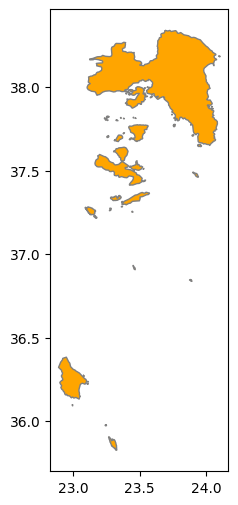

In [10]:
greece_cm_gdf.plot(facecolor="none", edgecolor='grey', figsize=(6,6), color='orange')

In [11]:
greece_cm_lv3 = gpd.read_file(r"E:\Drive\NOA\Shapefiles\Greece Shapefiles\EL_NUTS3.shp",  encoding=enc)
greece_cm_lv3 = greece_cm_lv3[greece_cm_lv3['NUTS_ID'].str.startswith(NUTS2_ID, na=False)]
greece_cm_lv3.reset_index(drop=True, inplace=True) 

In [12]:
greece_cm_lv3.head()

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,CNTR_NAME,geometry
0,EL301,EL,Voreios Tomeas Athinon,Βόρειος Τομέας Αθηνών,4.0,1,2,Greece,"POLYGON ((23.82310 37.97392, 23.80300 37.98545..."
1,EL302,EL,Dytikos Tomeas Athinon,Δυτικός Τομέας Αθηνών,4.0,1,1,Greece,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38..."
2,EL305,EL,Anatoliki Attiki,Ανατολική Αττική,2.0,1,1,Greece,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."
3,EL306,EL,Dytiki Attiki,Δυτική Αττική,2.0,1,1,Greece,"MULTIPOLYGON (((23.63450 38.21134, 23.63721 38..."
4,EL304,EL,Notios Tomeas Athinon,Νότιος Τομέας Αθηνών,4.0,1,1,Greece,"POLYGON ((23.80679 37.91784, 23.80240 37.91205..."


In [13]:
greece_cm_lv3 = greece_cm_lv3.to_crs(epsg=4326)
greece_cm_lv3.drop(columns=['CNTR_CODE', 'NUTS_NAME', 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE', 'CNTR_NAME'], inplace=True)

greece_cm_lv3.rename(columns={'NUTS_ID': 'div3_code',
                              'NAME_LATN': 'div3_name'}, inplace=True)

greece_cm_lv3['div3_name'] = greece_cm_lv3['div3_name'].str.lower()
greece_cm_lv3['div3_name'] = greece_cm_lv3['div3_name'].apply(lambda x : remove_accents(x))

greece_cm_lv3['div0_name'] = 'ellada'
greece_cm_lv3['div0_code'] = 'EL'
greece_cm_lv3['div1_name'] = 'attiki'
greece_cm_lv3['div1_code'] = 'EL3'
greece_cm_lv3['div2_name'] = 'attiki'
greece_cm_lv3['div2_code'] = 'EL30'

In [14]:
greece_cm_lv3 = greece_cm_lv3[['div0_code', 'div0_name',
                               'div1_code', 'div1_name',
                               'div2_code', 'div2_name',
                               'div3_code', 'div3_name',
                               'geometry']].copy()

In [15]:
greece_cm_lv3

,div0_code,div0_name,div1_code,div1_name,div2_code,div2_name,div3_code,div3_name,geometry
0,EL,ellada,EL3,attiki,EL30,attiki,EL301,voreios tomeas athinon,"POLYGON ((23.82310 37.97392, 23.80300 37.98545..."
1,EL,ellada,EL3,attiki,EL30,attiki,EL302,dytikos tomeas athinon,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38..."
2,EL,ellada,EL3,attiki,EL30,attiki,EL305,anatoliki attiki,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."
3,EL,ellada,EL3,attiki,EL30,attiki,EL306,dytiki attiki,"MULTIPOLYGON (((23.63450 38.21134, 23.63721 38..."
4,EL,ellada,EL3,attiki,EL30,attiki,EL304,notios tomeas athinon,"POLYGON ((23.80679 37.91784, 23.80240 37.91205..."
5,EL,ellada,EL3,attiki,EL30,attiki,EL307,"peiraias, nisoi","MULTIPOLYGON (((23.93391 37.47779, 23.94228 37..."
6,EL,ellada,EL3,attiki,EL30,attiki,EL303,kentrikos tomeas athinon,"POLYGON ((23.82310 37.97392, 23.82185 37.97195..."


<Axes: >

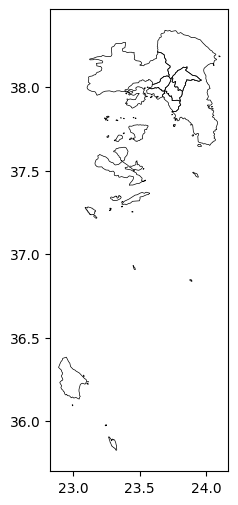

In [16]:
greece_cm_lv3.plot(facecolor="none", edgecolor='black', lw=0.5, figsize=(6,6), color='none')

In [17]:
greece_cm_lv4 = gpd.read_file(r"E:\Drive\NOA\Shapefiles\Greece Shapefiles\old\el_lau1.shp",  encoding=enc)
process_greek(greece_cm_lv4, 'NAME')
greece_cm_lv4_buffered = greece_cm_lv4.copy()
greece_cm_lv4_buffered = greece_cm_lv4_buffered.to_crs("EPSG:3035") 
greece_cm_lv4_buffered["geometry"] = greece_cm_lv4_buffered.geometry.buffer(-350)

In [18]:
greece_cm_lv4_buffered = greece_cm_lv4_buffered[~greece_cm_lv4_buffered.is_empty & greece_cm_lv4_buffered.is_valid]
greece_cm_lv4.shape == greece_cm_lv4_buffered.shape

True

In [19]:
greece_cm_lv4_buffered = greece_cm_lv4_buffered.to_crs("EPSG:4326") 
cm = greece_cm_gdf.geometry.iloc[0]
greece_cm_lv4_buffered = greece_cm_lv4_buffered[greece_cm_lv4_buffered.covered_by(cm)]
greece_cm_lv4_buffered.reset_index(drop=True, inplace=True)

<Axes: >

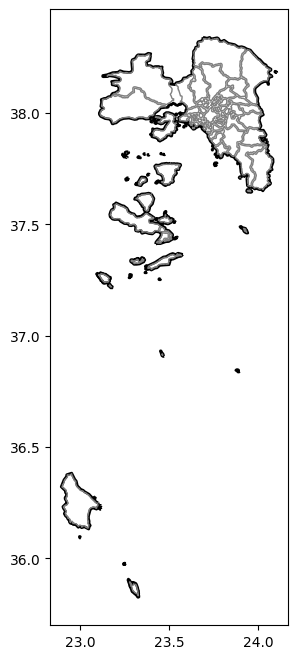

In [20]:
ax = greece_cm_gdf.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=2)
greece_cm_lv4_buffered.plot(facecolor="none", edgecolor='grey', ax=ax, color='none')

In [21]:
kwd_ypes = greece_cm_lv4_buffered.KWD_YPES.to_list()

In [22]:
## This addition is due to missmatching geometries after buffering

## we are manually adding the missing KWD_YPES 9229 Dimos Elefsinas

kwd_ypes.append('9229')

In [23]:
greece_cm_lv4 = greece_cm_lv4[greece_cm_lv4['KWD_YPES'].isin(kwd_ypes)].copy()
greece_cm_lv4.rename(columns={'KWD_YPES': 'div4_code',
                             'NAME': 'div4_name'}, inplace=True)
greece_cm_lv4 = greek_to_english(greece_cm_lv4, "div4_name")
greece_cm_lv4.reset_index(drop=True, inplace=True)

In [24]:
greece_cm_lv4

,div4_name,div4_code,geometry
0,ilioy,9182,"POLYGON ((23.68392 38.06429, 23.68763 38.06131..."
1,ydras,9214,"MULTIPOLYGON (((23.40645 37.29497, 23.40642 37..."
2,aiginas,9208,"MULTIPOLYGON (((23.31935 37.80028, 23.31914 37..."
3,agias varvaras,9179,"POLYGON ((23.64394 37.99855, 23.64396 37.99856..."
4,agias paraskeyis,9167,"POLYGON ((23.84009 38.02410, 23.84021 38.02408..."
...,...,...,...
61,filotheis psychikoy,9177,"POLYGON ((23.78121 38.00972, 23.78145 38.00970..."
62,fylis,9232,"POLYGON ((23.63902 38.20994, 23.64270 38.20955..."
63,chaidarioy,9185,"POLYGON ((23.65604 38.03663, 23.65608 38.03649..."
64,chalandrioy,9178,"POLYGON ((23.84912 38.04284, 23.84926 38.04279..."


<Axes: >

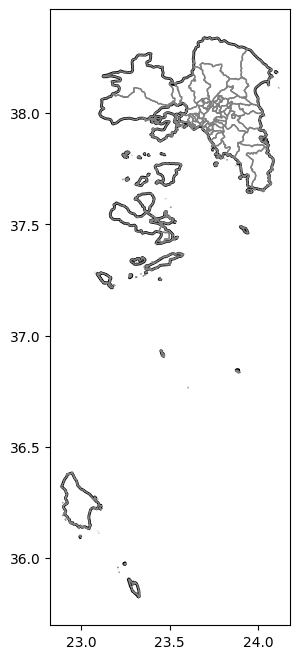

In [25]:
ax = greece_cm_gdf.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=2)
greece_cm_lv4.plot(facecolor="none", edgecolor='grey', ax=ax, color='none')

In [26]:
## GPT Code to enrich lv4 with lv3 attributes

# -------------------------------------------------------------------
# Inputs (already in memory):
#   greece_cm_lv3: polygons with div0..div3 + geometry
#   greece_cm_lv4: polygons with div4 + geometry
# Output:
#   greece_cm_lv4_enriched: lv4 with div0..div3 columns added
# -------------------------------------------------------------------

ADMIN_COLS = [
    "div0_code", "div0_name",
    "div1_code", "div1_name",
    "div2_code", "div2_name",
    "div3_code", "div3_name",
]

# 1) Ensure CRS is set and aligned
if greece_cm_lv3.crs is None or greece_cm_lv4.crs is None:
    raise ValueError(
        "One of the GeoDataFrames has no CRS set. "
        "Set it first with .set_crs(..., inplace=True) before running this."
    )

if greece_cm_lv3.crs != greece_cm_lv4.crs:
    greece_cm_lv4 = greece_cm_lv4.to_crs(greece_cm_lv3.crs)

# 2) Compute inside-points for lv4 (use representative_point to guarantee inside)
lv4 = greece_cm_lv4.copy()
crs_orig = lv4.crs

# For accurate point computations, do it in a metric CRS if current CRS is geographic
if crs_orig.is_geographic:
    # ETRS89 / LAEA Europe (meters) - safe default for Europe/Greece
    lv4_metric = lv4.to_crs(3035)
    lv4_metric["__pt"] = lv4_metric.geometry.representative_point()
    lv4["__pt"] = lv4_metric["__pt"].to_crs(crs_orig)
else:
    lv4["__pt"] = lv4.geometry.representative_point()

lv4_pts = gpd.GeoDataFrame(
    lv4[["div4_code", "div4_name", "__pt"]].copy(),
    geometry="__pt",
    crs=crs_orig,
)

# 3) Spatial join: which lv3 polygon contains the lv4 inside-point?
lv3_for_join = greece_cm_lv3[ADMIN_COLS + ["geometry"]].copy()

# If you suspect invalid geometries in lv3, uncomment:
# lv3_for_join["geometry"] = lv3_for_join.geometry.make_valid()

joined = (
    gpd.sjoin(
        lv4_pts,
        lv3_for_join,
        how="left",
        predicate="within",   # point within polygon
    )
    .drop(columns=["index_right"], errors="ignore")
)

# 4) Merge attributes back onto lv4 polygons
greece_cm_lv4_enriched = (
    greece_cm_lv4
    .merge(joined[["div4_code"] + ADMIN_COLS], on="div4_code", how="left")
)

# 5) Quick diagnostics
missing = greece_cm_lv4_enriched[ADMIN_COLS].isna().any(axis=1)
print(f"Unmatched LV4 rows (no containing LV3 polygon found): {missing.sum()} / {len(missing)}")


Unmatched LV4 rows (no containing LV3 polygon found): 0 / 66


In [27]:
greece_cm_lv4 = greece_cm_lv4_enriched[['div0_name', 'div1_name', 'div2_name', 'div3_name', 'div4_name', 'div0_code', 'div1_code', 'div2_code', 'div3_code', 'div4_code', 'geometry']].copy()

In [28]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

In [29]:
df_grid_cm_d2 = create_grid(empty_gdf, greece_cm_gdf, col_municipal='div0_name', dimension=2)

In [30]:
df_grid_cm_d2.head()

,geometry,centers,div0_name,x,y,resolution_km
0,"POLYGON ((22.93644 36.22024, 22.93644 36.23821...",POINT (22.925364464318083 36.22922756100483),ellada,22.92536,36.22923,2
1,"POLYGON ((22.93644 36.31008, 22.93644 36.32804...",POINT (22.925364464318083 36.3190610190059),ellada,22.92536,36.31906,2
2,"POLYGON ((22.93644 36.32804, 22.93644 36.34601...",POINT (22.925364464318083 36.337027710606115),ellada,22.92536,36.33703,2
3,"POLYGON ((22.95860 36.18431, 22.95860 36.20228...",POINT (22.947523440530137 36.1932941778044),ellada,22.94752,36.19329,2
4,"POLYGON ((22.95860 36.20228, 22.95860 36.22024...",POINT (22.947523440530137 36.21126086940461),ellada,22.94752,36.21126,2


In [31]:
df_grid_cm_d2.shape

(737, 6)

<Axes: >

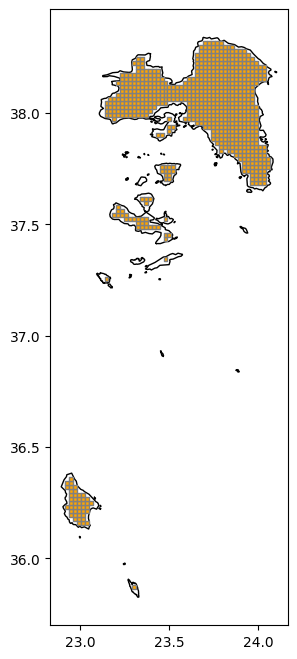

In [32]:
ax = greece_cm_gdf.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=1)
df_grid_cm_d2.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [33]:
df_grid_cm_d2.set_geometry('centers', inplace=True)
df_grid_cm_d2.set_crs(epsg=4326, inplace=True)

,geometry,centers,div0_name,x,y,resolution_km
0,"POLYGON ((22.93644 36.22024, 22.93644 36.23821...",POINT (22.92536 36.22923),ellada,22.92536,36.22923,2
1,"POLYGON ((22.93644 36.31008, 22.93644 36.32804...",POINT (22.92536 36.31906),ellada,22.92536,36.31906,2
2,"POLYGON ((22.93644 36.32804, 22.93644 36.34601...",POINT (22.92536 36.33703),ellada,22.92536,36.33703,2
3,"POLYGON ((22.95860 36.18431, 22.95860 36.20228...",POINT (22.94752 36.19329),ellada,22.94752,36.19329,2
4,"POLYGON ((22.95860 36.20228, 22.95860 36.22024...",POINT (22.94752 36.21126),ellada,22.94752,36.21126,2
...,...,...,...,...,...,...
732,"POLYGON ((24.04439 38.17861, 24.04439 38.19658...",POINT (24.03331 38.18760),ellada,24.03331,38.18760,2
733,"POLYGON ((24.04439 38.19658, 24.04439 38.21455...",POINT (24.03331 38.20556),ellada,24.03331,38.20556,2
734,"POLYGON ((24.06655 37.74741, 24.06655 37.76538...",POINT (24.05547 37.75640),ellada,24.05547,37.75640,2
735,"POLYGON ((24.06655 37.76538, 24.06655 37.78335...",POINT (24.05547 37.77436),ellada,24.05547,37.77436,2


In [34]:
greece_cm_grid = gpd.sjoin(df_grid_cm_d2, greece_cm_lv4, how='left', op='within')

In [35]:
greece_cm_grid.head()

,geometry,centers,div0_name_left,x,y,resolution_km,index_right,div0_name_right,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code
0,"POLYGON ((22.93644 36.22024, 22.93644 36.23821...",POINT (22.92536 36.22923),ellada,22.92536,36.22923,2,32,ellada,attiki,attiki,"peiraias, nisoi",kythiron,EL,EL3,EL30,EL307,9209
1,"POLYGON ((22.93644 36.31008, 22.93644 36.32804...",POINT (22.92536 36.31906),ellada,22.92536,36.31906,2,32,ellada,attiki,attiki,"peiraias, nisoi",kythiron,EL,EL3,EL30,EL307,9209
2,"POLYGON ((22.93644 36.32804, 22.93644 36.34601...",POINT (22.92536 36.33703),ellada,22.92536,36.33703,2,32,ellada,attiki,attiki,"peiraias, nisoi",kythiron,EL,EL3,EL30,EL307,9209
3,"POLYGON ((22.95860 36.18431, 22.95860 36.20228...",POINT (22.94752 36.19329),ellada,22.94752,36.19329,2,32,ellada,attiki,attiki,"peiraias, nisoi",kythiron,EL,EL3,EL30,EL307,9209
4,"POLYGON ((22.95860 36.20228, 22.95860 36.22024...",POINT (22.94752 36.21126),ellada,22.94752,36.21126,2,32,ellada,attiki,attiki,"peiraias, nisoi",kythiron,EL,EL3,EL30,EL307,9209


In [36]:
greece_cm_grid.dropna(inplace=True)

In [37]:
final_grid = greece_cm_grid[['x', 'y', 'div0_name_right', 'div1_name', 'div2_name', 'div3_name', 'div4_name', 'div0_code', 'div1_code', 'div2_code', 'div3_code', 'div4_code', 'resolution_km', 'centers', 'geometry']].copy()
final_grid.set_geometry('geometry', inplace=True)
final_grid.rename(columns={'div0_name_right': "div0_name"}, inplace=True)
final_grid.sort_values(by=['x', 'y', 'div4_name'], inplace = True)
final_grid.reset_index(drop=True, inplace=True)

<Axes: >

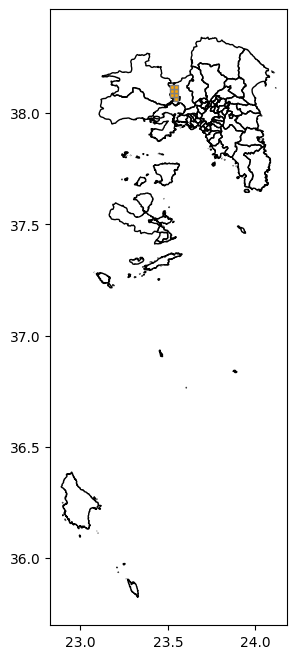

In [38]:
ax = greece_cm_lv4.plot(figsize=(8, 8), facecolor="none", edgecolor='black', lw=1)
final_grid[final_grid['div4_name'] == 'eleysinas'].plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [39]:
print(f'Shape of final_grid: {final_grid.div4_name.unique().shape}')
print(f'Shape of greece_cm_lv4: {greece_cm_lv4.div4_name.unique().shape}')

Shape of final_grid: (62,)
Shape of greece_cm_lv4: (66,)


In [40]:
diff = list(set(greece_cm_lv4.div4_name.unique().tolist()) - set(final_grid.div4_name.unique().tolist()))
print(f'Difference is: {len(diff)}')
print(f'Missing GIDs are: {diff}') 

Difference is: 4
Missing GIDs are: ['neas ionias', 'alimoy', 'agkistrioy', 'neas smyrnis']


In [41]:
missing_LAUs_d2 = greece_cm_lv4[greece_cm_lv4.div4_name.isin(diff)].copy()
missing_LAUs_d2.reset_index(drop=True, inplace=True)

In [42]:
missing_LAUs_d2

,div0_name,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code,geometry
0,ellada,attiki,attiki,"peiraias, nisoi",agkistrioy,EL,EL3,EL30,EL307,9207,"MULTIPOLYGON (((23.26062 37.70556, 23.26091 37..."
1,ellada,attiki,attiki,notios tomeas athinon,alimoy,EL,EL3,EL30,EL304,9195,"POLYGON ((23.74436 37.92837, 23.74478 37.91926..."
2,ellada,attiki,attiki,voreios tomeas athinon,neas ionias,EL,EL3,EL30,EL301,9174,"POLYGON ((23.75091 38.05065, 23.75105 38.05057..."
3,ellada,attiki,attiki,notios tomeas athinon,neas smyrnis,EL,EL3,EL30,EL304,9200,"POLYGON ((23.71448 37.95544, 23.72277 37.94899..."


In [43]:
missing_LAUs_d2["centers"] = missing_LAUs_d2.geometry.centroid

In [44]:
missing_LAUs_d2['resolution_km'] = 1

<Axes: >

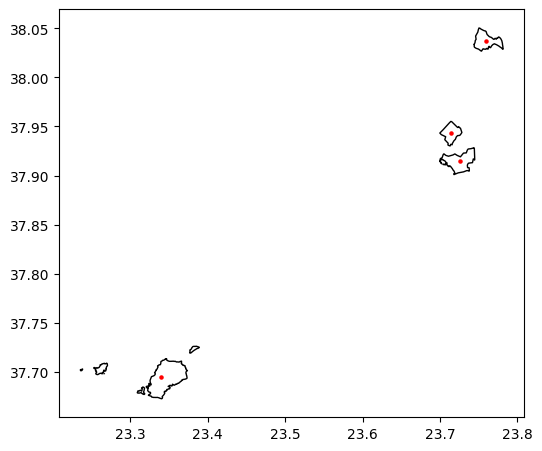

In [45]:
ax = missing_LAUs_d2.plot(edgecolor='black', facecolor='none', figsize=(6, 6))
missing_LAUs_d2['centers'].plot(ax=ax, color='red', markersize=5)

In [46]:
missing_LAUs_d2["x"] = missing_LAUs_d2["centers"].x
missing_LAUs_d2["y"] = missing_LAUs_d2["centers"].y
missing_LAUs_d2 = missing_LAUs_d2[['x', 'y', 'div0_name', 'div1_name', 'div2_name', 'div3_name', 'div4_name', 'div0_code', 'div1_code', 'div2_code', 'div3_code', 'div4_code', 'resolution_km', 'centers', 'geometry']]



In [47]:
missing_LAUs_d2.head()

,x,y,div0_name,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code,resolution_km,centers,geometry
0,23.340091,37.695034,ellada,attiki,attiki,"peiraias, nisoi",agkistrioy,EL,EL3,EL30,EL307,9207,1,POINT (23.34009 37.69503),"MULTIPOLYGON (((23.26062 37.70556, 23.26091 37..."
1,23.725812,37.914704,ellada,attiki,attiki,notios tomeas athinon,alimoy,EL,EL3,EL30,EL304,9195,1,POINT (23.72581 37.91470),"POLYGON ((23.74436 37.92837, 23.74478 37.91926..."
2,23.759536,38.037284,ellada,attiki,attiki,voreios tomeas athinon,neas ionias,EL,EL3,EL30,EL301,9174,1,POINT (23.75954 38.03728),"POLYGON ((23.75091 38.05065, 23.75105 38.05057..."
3,23.714423,37.943383,ellada,attiki,attiki,notios tomeas athinon,neas smyrnis,EL,EL3,EL30,EL304,9200,1,POINT (23.71442 37.94338),"POLYGON ((23.71448 37.95544, 23.72277 37.94899..."


In [48]:
final_grid = pd.concat([final_grid, missing_LAUs_d2], ignore_index=True)

In [49]:
print(f'Shape of final_grid: {final_grid.div4_name.unique().shape}')
print(f'Shape of cameroon_nord_lv3: {greece_cm_lv4.div4_name.unique().shape}')

Shape of final_grid: (66,)
Shape of cameroon_nord_lv3: (66,)


In [50]:
final_grid.sort_values(by=['div2_code', 'div3_code', 'div4_code', 'x', 'y'], inplace = True)
final_grid.rename(columns={'x': 'longitude', 'y': 'latitude'}, inplace=True)
final_grid.reset_index(drop=True, inplace=True)
final_grid.drop(columns=['centers'], inplace=True)
final_grid

,longitude,latitude,div0_name,div1_name,div2_name,div3_name,div4_name,div0_code,div1_code,div2_code,div3_code,div4_code,resolution_km,geometry
0,23.81172,38.00793,ellada,attiki,attiki,voreios tomeas athinon,agias paraskeyis,EL,EL3,EL30,EL301,9167,2,"POLYGON ((23.82280 37.99895, 23.82280 38.01691..."
1,23.83388,38.00793,ellada,attiki,attiki,voreios tomeas athinon,agias paraskeyis,EL,EL3,EL30,EL301,9167,2,"POLYGON ((23.84496 37.99895, 23.84496 38.01691..."
2,23.78956,38.04386,ellada,attiki,attiki,voreios tomeas athinon,amaroysioy,EL,EL3,EL30,EL301,9168,2,"POLYGON ((23.80064 38.03488, 23.80064 38.05285..."
3,23.81172,38.04386,ellada,attiki,attiki,voreios tomeas athinon,amaroysioy,EL,EL3,EL30,EL301,9168,2,"POLYGON ((23.82280 38.03488, 23.82280 38.05285..."
4,23.81172,38.06183,ellada,attiki,attiki,voreios tomeas athinon,amaroysioy,EL,EL3,EL30,EL301,9168,2,"POLYGON ((23.82280 38.05285, 23.82280 38.07081..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
736,23.39070,37.61266,ellada,attiki,attiki,"peiraias, nisoi",troizinias,EL,EL3,EL30,EL307,9213,2,"POLYGON ((23.40178 37.60368, 23.40178 37.62165..."
737,23.41286,37.48690,ellada,attiki,attiki,"peiraias, nisoi",troizinias,EL,EL3,EL30,EL307,9213,2,"POLYGON ((23.42394 37.47791, 23.42394 37.49588..."
738,23.43502,37.48690,ellada,attiki,attiki,"peiraias, nisoi",troizinias,EL,EL3,EL30,EL307,9213,2,"POLYGON ((23.44610 37.47791, 23.44610 37.49588..."
739,23.47934,37.45096,ellada,attiki,attiki,"peiraias, nisoi",troizinias,EL,EL3,EL30,EL307,9213,2,"POLYGON ((23.49042 37.44198, 23.49042 37.45995..."


In [ ]:
final_grid.loc[final_grid['div3_name'] == 'peiraias, nisoi', 'div3_name'] = 'peiraias nisoi'
final_grid.loc[final_grid['div4_name'] == 'nikaias agioy i. renti', 'div4_name'] = 'nikaias agioy i renti'

string_cols = final_grid.select_dtypes(include=['object', 'string']).columns

final_grid[string_cols] = final_grid[string_cols].apply(lambda col: col.map(remove_accents))
final_grid[string_cols] = final_grid[string_cols].apply(lambda col: col.str.replace(r"[,.]", "", regex=True))

In [52]:
if final_grid['div3_code'].isnull().any():
    raise ValueError("div3_code contains NULL values, need rules to handle them.")

# Create a "counter" per div3_code
final_grid['counter'] = final_grid.groupby('div3_code').cumcount() + 1

# Convert counter to hex, padded to 5 digits
final_grid['hex_counter'] = final_grid['counter'].apply(lambda x: format(x, '05X'))

# Final point_code = div3_code + hex_counter
final_grid['point_code'] = final_grid['div3_code'] + final_grid['hex_counter']

# Drop helper columns
final_grid = final_grid.drop(columns=['counter', 'hex_counter'])

In [53]:
final_grid = final_grid[['point_code', 'latitude', 'longitude', 'div0_name', 'div0_code', 'div1_name', 'div1_code', 'div2_name', 'div2_code', 'div3_name', 'div3_code', 'div4_name','div4_code', 'resolution_km', 'geometry']].copy()

<Axes: >

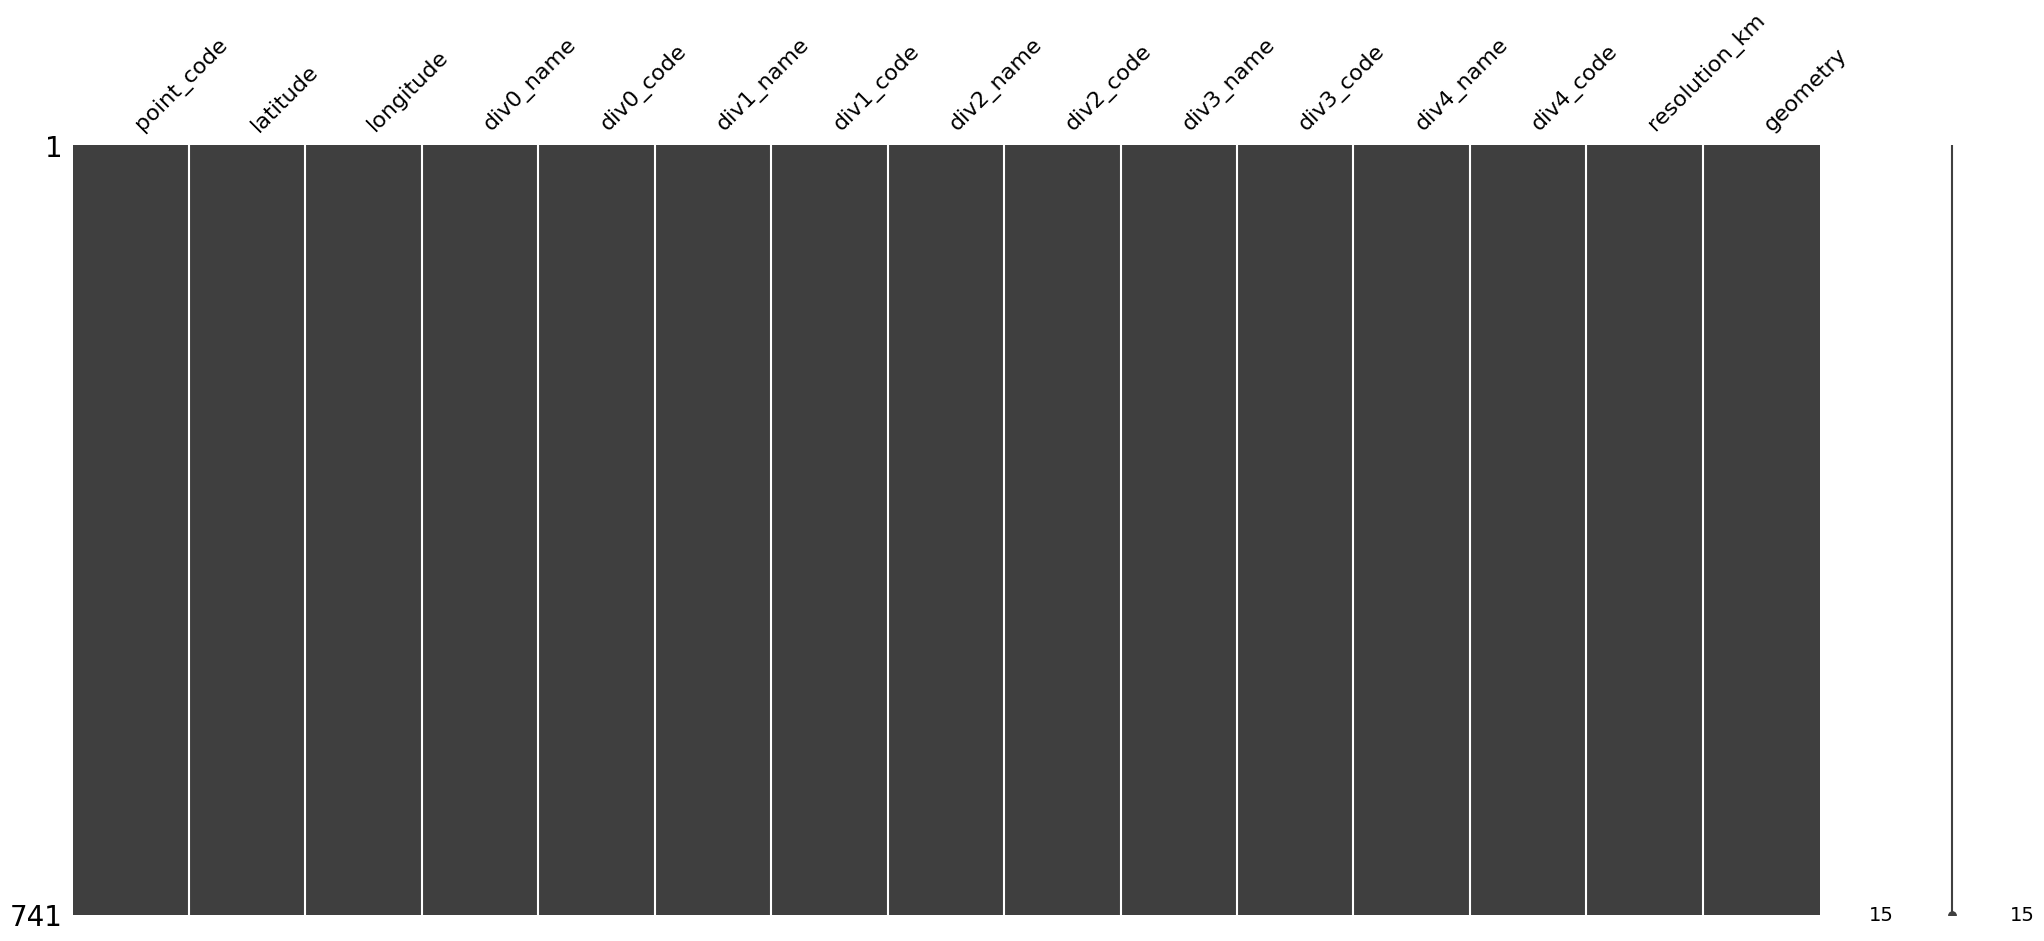

In [54]:
missingno.matrix(final_grid)

In [55]:
final_grid

,point_code,latitude,longitude,div0_name,div0_code,div1_name,div1_code,div2_name,div2_code,div3_name,div3_code,div4_name,div4_code,resolution_km,geometry
0,EL30100001,38.00793,23.81172,ellada,EL,attiki,EL3,attiki,EL30,voreios tomeas athinon,EL301,agias paraskeyis,9167,2,"POLYGON ((23.82280 37.99895, 23.82280 38.01691..."
1,EL30100002,38.00793,23.83388,ellada,EL,attiki,EL3,attiki,EL30,voreios tomeas athinon,EL301,agias paraskeyis,9167,2,"POLYGON ((23.84496 37.99895, 23.84496 38.01691..."
2,EL30100003,38.04386,23.78956,ellada,EL,attiki,EL3,attiki,EL30,voreios tomeas athinon,EL301,amaroysioy,9168,2,"POLYGON ((23.80064 38.03488, 23.80064 38.05285..."
3,EL30100004,38.04386,23.81172,ellada,EL,attiki,EL3,attiki,EL30,voreios tomeas athinon,EL301,amaroysioy,9168,2,"POLYGON ((23.82280 38.03488, 23.82280 38.05285..."
4,EL30100005,38.06183,23.81172,ellada,EL,attiki,EL3,attiki,EL30,voreios tomeas athinon,EL301,amaroysioy,9168,2,"POLYGON ((23.82280 38.05285, 23.82280 38.07081..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
736,EL30700064,37.61266,23.39070,ellada,EL,attiki,EL3,attiki,EL30,peiraias nisoi,EL307,troizinias,9213,2,"POLYGON ((23.40178 37.60368, 23.40178 37.62165..."
737,EL30700065,37.48690,23.41286,ellada,EL,attiki,EL3,attiki,EL30,peiraias nisoi,EL307,troizinias,9213,2,"POLYGON ((23.42394 37.47791, 23.42394 37.49588..."
738,EL30700066,37.48690,23.43502,ellada,EL,attiki,EL3,attiki,EL30,peiraias nisoi,EL307,troizinias,9213,2,"POLYGON ((23.44610 37.47791, 23.44610 37.49588..."
739,EL30700067,37.45096,23.47934,ellada,EL,attiki,EL3,attiki,EL30,peiraias nisoi,EL307,troizinias,9213,2,"POLYGON ((23.49042 37.44198, 23.49042 37.45995..."


In [56]:
final_grid.drop(columns='geometry').to_csv(f'../../data/{NUTS2}/GR_{NUTS2}_Grid_DB.csv', encoding=enc, index = False)
# final_grid.to_file(f'../data/CM_Nord_Grid.shp', encoding = 'utf-8')